<a href="https://colab.research.google.com/github/sejallotliker/Machine_learning_practice/blob/main/superconductivity_Tc_prediction/superconductivity_Tc_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/JNCASR/Sem-4/Intro_to_ML/Final_exam_practice/superconductivity data/train.csv")
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [26]:
df.isnull().sum()

,0
number_of_elements,0
mean_atomic_mass,0
wtd_mean_atomic_mass,0
gmean_atomic_mass,0
wtd_gmean_atomic_mass,0
...,...
range_Valence,0
wtd_range_Valence,0
std_Valence,0
wtd_std_Valence,0


No null values in the data

In [27]:
df.columns

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie      

<Axes: >

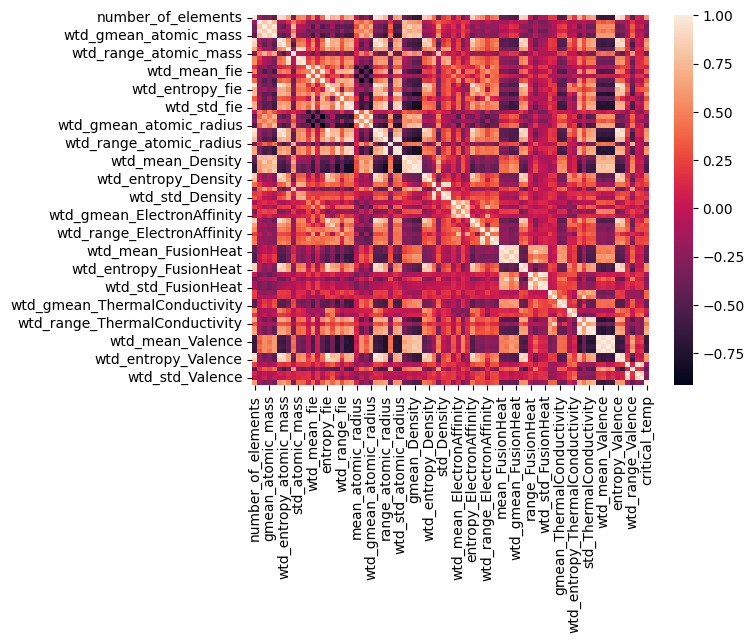

In [29]:
import seaborn as sns
sns.heatmap(df.corr(method='pearson'))

In [30]:
#Correlation with critical temperature
df.corr()['critical_temp'].sort_values(ascending=False)

,critical_temp
critical_temp,1.000000
wtd_std_ThermalConductivity,0.721271
range_ThermalConductivity,0.687654
range_atomic_radius,0.653759
std_ThermalConductivity,0.653632
...,...
gmean_Density,-0.541684
gmean_Valence,-0.573068
mean_Valence,-0.600085
wtd_gmean_Valence,-0.615653


In [31]:
#To divide the data into test and train
x = df.drop('critical_temp', axis=1)
y = df['critical_temp']

In [32]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
#We don't need one hot encoder since the data is fully numerical

In [34]:
numerical_cols = x.select_dtypes(include=['int64', 'float64']).columns

In [35]:
numerical_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [36]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('numerical', numerical_preprocessor, numerical_cols)
])

In [38]:
#Since it's a regression problem, we can apply regression models
from sklearn.linear_model import LinearRegression
model_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
model_1.fit(x_train, y_train)
y_pred_lr = model_1.predict(x_test)


#To test accuracy {Linear regression}
from sklearn.metrics import root_mean_squared_error, r2_score
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("Root Mean Squared Error for Linear regression:", rmse_lr)
print("R-squared for linear regression:", r2_lr)

Root Mean Squared Error for Linear regression: 17.37836334497927
R-squared for linear regression: 0.7376312737139081


In [45]:
#Decision tree regressor
from sklearn.tree import DecisionTreeRegressor
model_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('Decision tree regressor', DecisionTreeRegressor(random_state=42))
])
model_2.fit(x_train, y_train)
y_pred_dtr = model_2.predict(x_test)

#To test accuracy {Decision tree regressor}
from sklearn.metrics import root_mean_squared_error, r2_score
rmse_dtr = root_mean_squared_error(y_test, y_pred_dtr)
r2_dtr = r2_score(y_test, y_pred_dtr)
print("Root Mean Squared Error for decision tree regression:", rmse_dtr)
print("R-squared for decision tree regression:", r2_dtr)

Root Mean Squared Error for decision tree regression: 11.636776853015956
R-squared for decision tree regression: 0.8823587221338897


In [47]:
#Random forest regressor
from sklearn.ensemble import RandomForestRegressor
model_3 = Pipeline([
    ('preprocessor', preprocessor),
    ('Random forest regressor', RandomForestRegressor(random_state=42))
])

In [48]:
model_3.fit(x_train, y_train)
y_pred_rf = model_3.predict(x_test)

#To test accuracy
from sklearn.metrics import root_mean_squared_error, r2_score
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Root Mean Squared Error for random forest regression:", rmse_rf)
print("R-squared for linear regression:", r2_rf)

Root Mean Squared Error for random forest regression: 9.017987681817402
R-squared for linear regression: 0.9293497673843398


In [49]:
#SVR
from sklearn.svm import SVR
model_4 = Pipeline([
    ('preprocessor', preprocessor),
    ('Support vector regressor', SVR())
])

In [50]:
#To fit the model with best parameters
model_4.fit(x_train, y_train)
y_pred_SVR = model_4.predict(x_test)

#To test accuracy
from sklearn.metrics import root_mean_squared_error, r2_score
rmse_SVR = root_mean_squared_error(y_test, y_pred_SVR)
r2_SVR = r2_score(y_test, y_pred_SVR)
print("Root Mean Squared Error for random forest regression:", rmse_SVR)
print("R-squared for linear regression:", r2_SVR)

Root Mean Squared Error for random forest regression: 15.776779949605036
R-squared for linear regression: 0.7837624774804379


In [51]:
#KNR
from sklearn.neighbors import KNeighborsRegressor
model_5 = Pipeline([
    ('preprocessor', preprocessor),
    ('K neighbors regressor', KNeighborsRegressor())
])

In [52]:
#To fit the model with best parameters
model_5.fit(x_train, y_train)
y_pred_KNR = model_5.predict(x_test)

#To test accuracy
from sklearn.metrics import root_mean_squared_error, r2_score
rmse_KNR = root_mean_squared_error(y_test, y_pred_KNR)
r2_KNR = r2_score(y_test, y_pred_KNR)
print("Root Mean Squared Error for KNR:", rmse_KNR)
print("R-squared for KNR:", r2_KNR)

Root Mean Squared Error for random forest regression: 10.438788226805062
R-squared for linear regression: 0.905333898015418


In [54]:
#GBR
from sklearn.ensemble import GradientBoostingRegressor
model_6 = Pipeline([
    ('preprocessor', preprocessor),
    ('Gradient boosting regressor', GradientBoostingRegressor(random_state=42))
])

In [55]:
#To fit the model with best parameters
model_6.fit(x_train, y_train)
y_pred_gbr = model_6.predict(x_test)

#To test accuracy
from sklearn.metrics import root_mean_squared_error, r2_score
rmse_gbr = root_mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)
print("Root Mean Squared Error for GBR:", rmse_gbr)
print("R-squared for GBR:", r2_gbr)

Root Mean Squared Error for GBR: 12.332734699242069
R-squared for GBR: 0.8678664513477218


In [57]:
#ABR
from sklearn.ensemble import AdaBoostRegressor
model_7 = Pipeline([
    ('preprocessor', preprocessor),
    ('Ada boost regressor', AdaBoostRegressor(random_state=42))
])

In [58]:
#To fit the model with best parameters
model_7.fit(x_train, y_train)
y_pred_abr = model_7.predict(x_test)

#To test accuracy
from sklearn.metrics import root_mean_squared_error, r2_score
rmse_abr = root_mean_squared_error(y_test, y_pred_abr)
r2_abr = r2_score(y_test, y_pred_abr)
print("Root Mean Squared Error for ABR:", rmse_abr)
print("R-squared for ABR:", r2_abr)

Root Mean Squared Error for ABR: 19.79223804427787
R-squared for ABR: 0.659682617783738


In [59]:
#Bagging regressor
from sklearn.ensemble import BaggingRegressor
model_8 = Pipeline([
    ('preprocessor', preprocessor),
    ('Bagging regressor', BaggingRegressor(random_state=42))
])

In [60]:
#To fit the model with best parameters
model_8.fit(x_train, y_train)
y_pred_bagg_regr = model_8.predict(x_test)


#To test accuracy
from sklearn.metrics import root_mean_squared_error, r2_score
rmse_bagg_regr = root_mean_squared_error(y_test, y_pred_bagg_regr)
r2_bagg_regr = r2_score(y_test, y_pred_bagg_regr)
print("Root Mean Squared Error for Bagging regressor:", rmse_bagg_regr)
print("R-squared for Bagging regressor:", r2_bagg_regr)

Root Mean Squared Error for Bagging regressor: 9.386019225393392
R-squared for Bagging regressor: 0.9234655087758943


In [61]:
#To compare all the 8 models used:
model_names = ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor',
               'Support Vector Regressor', 'K Neighbors Regressor', 'Gradient Boosting Regressor',
               'Ada Boost Regressor', 'Bagging Regressor']
rmse_values = [rmse_lr, rmse_dtr, rmse_rf, rmse_SVR, rmse_KNR, rmse_gbr, rmse_abr, rmse_bagg_regr]
r2_values = [r2_lr, r2_dtr, r2_rf, r2_SVR, r2_KNR, r2_gbr, r2_abr, r2_bagg_regr]

# To Create a DataFrame for better visualization
results = pd.DataFrame({
    'Model': model_names,
    'RMSE': rmse_values,
    'R-squared': r2_values
})
print(results)

                         Model       RMSE  R-squared
0            Linear Regression  17.378363   0.737631
1      Decision Tree Regressor  11.636777   0.882359
2      Random Forest Regressor   9.017988   0.929350
3     Support Vector Regressor  15.776780   0.783762
4        K Neighbors Regressor  10.438788   0.905334
5  Gradient Boosting Regressor  12.332735   0.867866
6          Ada Boost Regressor  19.792238   0.659683
7            Bagging Regressor   9.386019   0.923466


In [64]:
#To do feature importance
feature_importances = model_3.named_steps['Random forest regressor'].feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df

,Feature,Importance
0,number_of_elements,0.000040
1,mean_atomic_mass,0.000951
2,wtd_mean_atomic_mass,0.007082
3,gmean_atomic_mass,0.001638
4,wtd_gmean_atomic_mass,0.003071
...,...,...
76,wtd_entropy_Valence,0.003744
77,range_Valence,0.000254
78,wtd_range_Valence,0.010100
79,std_Valence,0.001168


Text(0, 0.5, 'Importance')

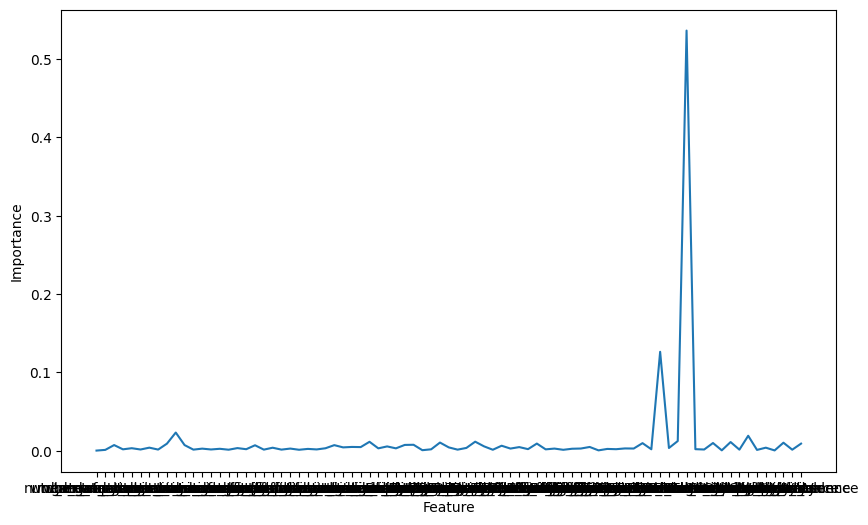

In [67]:
#To plot a graph of importance v/s feature
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')

In [75]:
#To take only those features which are above 0.02
important_features = feature_importance_df[feature_importance_df['Importance'] > 0.005]['Feature']
important_features

,Feature
2,wtd_mean_atomic_mass
8,wtd_range_atomic_mass
9,std_atomic_mass
10,wtd_std_atomic_mass
18,wtd_range_fie
27,range_atomic_radius
31,mean_Density
33,gmean_Density
35,entropy_Density
36,wtd_entropy_Density


In [81]:
important_features.unique()

array(['wtd_mean_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass',
       'wtd_std_atomic_mass', 'wtd_range_fie', 'range_atomic_radius',
       'mean_Density', 'gmean_Density', 'entropy_Density',
       'wtd_entropy_Density', 'std_Density', 'gmean_ElectronAffinity',
       'wtd_gmean_ElectronAffinity', 'wtd_entropy_ElectronAffinity',
       'wtd_std_ElectronAffinity', 'wtd_mean_ThermalConductivity',
       'wtd_gmean_ThermalConductivity', 'wtd_entropy_ThermalConductivity',
       'range_ThermalConductivity', 'wtd_std_ThermalConductivity',
       'wtd_mean_Valence', 'wtd_gmean_Valence', 'wtd_range_Valence',
       'wtd_std_Valence'], dtype=object)

#To apply model again after doing feature importance

In [106]:
df = pd.read_csv("/content/drive/MyDrive/JNCASR/Sem-4/Intro_to_ML/Final_exam_practice/superconductivity data/train.csv")
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [107]:
#To use all the models with only these 24 columns and 1 target
X_new = df[['wtd_mean_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass',
       'wtd_std_atomic_mass', 'wtd_range_fie', 'range_atomic_radius',
       'mean_Density', 'gmean_Density', 'entropy_Density',
       'wtd_entropy_Density', 'std_Density', 'gmean_ElectronAffinity',
       'wtd_gmean_ElectronAffinity', 'wtd_entropy_ElectronAffinity',
       'wtd_std_ElectronAffinity', 'wtd_mean_ThermalConductivity',
       'wtd_gmean_ThermalConductivity', 'wtd_entropy_ThermalConductivity',
       'range_ThermalConductivity', 'wtd_std_ThermalConductivity',
       'wtd_mean_Valence', 'wtd_gmean_Valence', 'wtd_range_Valence',
       'wtd_std_Valence']]
y_new = df['critical_temp']

In [108]:
from sklearn.model_selection import train_test_split
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [109]:
numerical_cols = X_new.select_dtypes(include=['int64', 'float64']).columns

In [110]:
numerical_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [111]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('numerical', numerical_preprocessor, numerical_cols)
])

In [112]:
#Random forest regressor
from sklearn.ensemble import RandomForestRegressor
model_3 = Pipeline([
    ('preprocessor', preprocessor),
    ('Random forest regressor', RandomForestRegressor(random_state=42))
])

In [113]:
model_3.fit(X_new_train, y_new_train )
y_pred_rf_new = model_3.predict(X_new_test)

#To test accuracy
from sklearn.metrics import root_mean_squared_error, r2_score
rmse_rf_new = root_mean_squared_error(y_new_test, y_pred_rf_new)
r2_rf_new = r2_score(y_new_test, y_pred_rf_new)
print("Root Mean Squared Error for random forest regression:", rmse_rf_new)
print("R-squared for linear regression:", r2_rf_new)

Root Mean Squared Error for random forest regression: 9.187568553060284
R-squared for linear regression: 0.9266676663398521


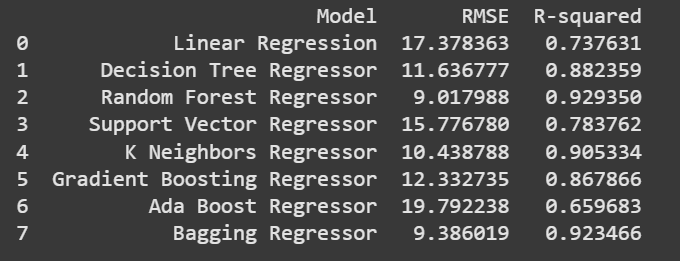

In [ ]:
#WE see that the accuracy has decreased after taking only few features